# UniversalXAS activation sweep: all candidates

This read-only notebook analyzes all nine UniversalXAS candidates. It compares `SiLU`, `GELU`, and `LeakyReLU(0.1)` with seeds 44, 45, and 46.

The completed activation sweep stores validation metrics for all nine candidates. It stores test metrics only for the validation-selected candidate. This notebook evaluates all nine candidates on the test split for reporting. It never uses test eta to select a candidate.

Eta is `median train-mean-spectrum baseline per-spectrum MSE / median model per-spectrum MSE`. Higher eta is better. The scope remains the eight FEFF datasets and fixed 64D custom exported features.


## 1. Imports and robust path resolution

The notebook reads source artifacts and checkpoint weights. It does not write CSV files, checkpoints, or other result files. It rebuilds checkpoint paths from candidate IDs and the local `candidates/` directory. Absolute paths stored in CSV and JSON files are not used.

Set `OMNIXAS_E2E_UNIVERSAL_RUN` when the archive run is at another location. Set `OMNIXAS_REPO_ROOT` when the repository cannot be found from the notebook working directory.


In [1]:
from __future__ import annotations
import os, sys, json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
try:
    display
except NameError:
    def display(value): print(value)

FEFF_TASKS=["Ti_FEFF","V_FEFF","Cr_FEFF","Mn_FEFF","Fe_FEFF","Co_FEFF","Ni_FEFF","Cu_FEFF"]
ELEMENTS=[x.removesuffix("_FEFF") for x in FEFF_TASKS]
SPLITS=["train","val","test"]
INPUT_DIM, OUTPUT_DIM=64,141
HIDDEN_DIMS=[500,500,550]
DROPOUT=0.10
ACTIVATIONS=["SiLU","GELU","LeakyReLU(0.1)"]
SEEDS=[44,45,46]
PAPER_UNIVERSAL_ETA={"Ti":4.19,"V":5.19,"Cr":7.13,"Mn":13.15,"Fe":6.04,"Co":9.58,"Ni":6.43,"Cu":2.75}

def is_repo_root(path):
    return (path/"pyproject.toml").is_file() and (path/"omnixas").is_dir() and (path/"tutorial_omnixas").is_dir()
def find_repo_root():
    override=os.environ.get("OMNIXAS_REPO_ROOT")
    if override:
        path=Path(override).expanduser().resolve()
        if not is_repo_root(path): raise FileNotFoundError(f"OMNIXAS_REPO_ROOT is not an OmniXAS repository: {path}")
        return path
    cwd=Path.cwd().resolve()
    try:
        notebook_dir=Path(__file__).resolve().parent
    except NameError:
        notebook_dir=cwd
    for path in [notebook_dir,*notebook_dir.parents,cwd,*cwd.parents,cwd/"OmniXAS",cwd/"omnixas",cwd/".."]:
        path=path.resolve()
        if is_repo_root(path): return path
    raise FileNotFoundError("Could not find the OmniXAS repository. Set OMNIXAS_REPO_ROOT.")

REPO_ROOT=find_repo_root(); sys.path.insert(0,str(REPO_ROOT))
ARCHIVE_RUN=Path(os.environ.get("OMNIXAS_E2E_UNIVERSAL_RUN",REPO_ROOT.parent/"fullTrainingCopy072726"/"m3gnetAll8E2EUniversal"/"e2e_universal_seed42")).expanduser().resolve()
SWEEP_ROOT=ARCHIVE_RUN/"notebook_activation_sweep"; RESULTS_DIR=SWEEP_ROOT/"results"; CANDIDATES_DIR=SWEEP_ROOT/"candidates"
FEATURES_DIR=ARCHIVE_RUN/"features"; ID_DIR=REPO_ROOT/"tutorial_omnixas"/"material_id_and_site"; CANONICAL_Y_DIR=REPO_ROOT/"tutorial_omnixas"/"ml_data"
SOURCE_RUN=ARCHIVE_RUN; BALANCED_REFERENCE_PATH=SOURCE_RUN/"train_balanced_gelu_universal_tuned_feff"/"universal_eval.csv"
for path,label in [(ARCHIVE_RUN,"archive run"),(SWEEP_ROOT,"activation sweep"),(RESULTS_DIR,"results"),(CANDIDATES_DIR,"candidate checkpoints"),(FEATURES_DIR,"exported features"),(ID_DIR,"material/site IDs"),(CANONICAL_Y_DIR,"canonical ML data")]:
    if not path.is_dir(): raise FileNotFoundError(f"Missing {label}: {path}")
print("Repository:",REPO_ROOT); print("Archive run:",ARCHIVE_RUN); print("Activation sweep:",SWEEP_ROOT)


Repository: /mnt/c/Users/anton/desktop/omnixas
Archive run: /mnt/c/Users/anton/desktop/fullTrainingCopy072726/m3gnetAll8E2EUniversal/e2e_universal_seed42
Activation sweep: /mnt/c/Users/anton/desktop/fullTrainingCopy072726/m3gnetAll8E2EUniversal/e2e_universal_seed42/notebook_activation_sweep


## 2. Load and validate the sweep manifest and CSV artifacts

The manifest records the sweep configuration. The candidate summary and validation files provide validation metrics for every candidate and every FEFF dataset. The `checkpoint` columns are informational only because they can contain stale absolute paths.


In [2]:
def read_json(path):
    if not path.is_file(): raise FileNotFoundError(f"Missing JSON artifact: {path}")
    return json.loads(path.read_text(encoding="utf-8"))
def require_columns(frame, columns, label):
    missing=sorted(set(columns)-set(frame.columns))
    if missing: raise ValueError(f"{label} is missing columns: {missing}")
def finite(frame, columns, label):
    for column in columns:
        values=pd.to_numeric(frame[column],errors="coerce").to_numpy(float)
        if not np.isfinite(values).all(): raise ValueError(f"Non-finite values in {label}.{column}")

manifest_path=SWEEP_ROOT/"manifest.json"; summary_path=RESULTS_DIR/"candidate_summary.csv"; validation_path=RESULTS_DIR/"candidate_validation.csv"
manifest=read_json(manifest_path); candidate_summary_stored=pd.read_csv(summary_path); candidate_validation_stored=pd.read_csv(validation_path)
require_columns(candidate_summary_stored,["candidate","activation","seed","checkpoint","mean_val_eta"],"candidate_summary.csv")
require_columns(candidate_validation_stored,["candidate","activation","seed","dataset","checkpoint","val_median_mse","val_baseline_median_mse","val_eta"],"candidate_validation.csv")
expected_candidates=pd.DataFrame([{"candidate":f"{a.lower().replace('(0.1)','_0p1')}_seed{s}","activation":a,"seed":s} for a in ACTIVATIONS for s in SEEDS])
expected_ids=set(expected_candidates.candidate)
if manifest.get("candidate_count")!=9: raise AssertionError(f"Manifest candidate_count is not 9: {manifest.get('candidate_count')}")
if manifest.get("tasks")!=FEFF_TASKS: raise AssertionError("Manifest task scope is not the eight fixed FEFF datasets")
if set(candidate_summary_stored.candidate)!=expected_ids or set(candidate_validation_stored.candidate)!=expected_ids: raise AssertionError("CSV candidate IDs are not the expected nine candidates")
if len(candidate_validation_stored)!=72: raise AssertionError(f"Expected 72 validation rows, got {len(candidate_validation_stored)}")
if set(candidate_validation_stored.dataset)!=set(FEFF_TASKS) or candidate_validation_stored.groupby("candidate").dataset.nunique().ne(8).any(): raise AssertionError("Validation rows do not cover all eight FEFF datasets")
finite(candidate_summary_stored,["seed","mean_val_eta"],"candidate_summary.csv"); finite(candidate_validation_stored,["seed","val_median_mse","val_baseline_median_mse","val_eta"],"candidate_validation.csv")
metadata=expected_candidates.merge(candidate_summary_stored.drop(columns=["activation","seed"],errors="ignore"),on="candidate",validate="one_to_one")
if metadata.mean_val_eta.isna().any() or set(metadata.activation)!=set(ACTIVATIONS) or set(metadata.seed)!=set(SEEDS): raise AssertionError("Candidate metadata is incomplete")
stored_means=candidate_validation_stored.groupby("candidate").val_eta.mean().reindex(metadata.candidate).to_numpy()
if not np.allclose(metadata.mean_val_eta,stored_means,rtol=0,atol=1e-10): raise AssertionError("candidate_summary mean_val_eta does not match candidate_validation.csv")
settings=manifest.get("settings",{}); source=manifest.get("source",{})
if settings.get("hidden_dims")!=HIDDEN_DIMS or settings.get("dropout")!=DROPOUT or source.get("feature_dim")!=INPUT_DIM or source.get("target_dim")!=OUTPUT_DIM: raise AssertionError("Manifest architecture dimensions do not match the sweep")
print(f"Loaded manifest and CSV artifacts: 9 candidates and {len(candidate_validation_stored)} validation rows.")
display(candidate_summary_stored[["candidate","activation","seed","mean_val_eta"]])


Loaded manifest and CSV artifacts: 9 candidates and 72 validation rows.


,candidate,activation,seed,mean_val_eta
0,gelu_seed44,GELU,44,16.834777
1,silu_seed46,SiLU,46,16.579853
2,gelu_seed45,GELU,45,16.465573
3,gelu_seed46,GELU,46,16.322279
4,silu_seed45,SiLU,45,16.261040
5,silu_seed44,SiLU,44,16.084007
6,leakyrelu_0p1_seed44,LeakyReLU(0.1),44,15.730123
7,leakyrelu_0p1_seed45,LeakyReLU(0.1),45,15.625260
8,leakyrelu_0p1_seed46,LeakyReLU(0.1),46,15.512472


## 3. Load fixed FEFF features, targets, and material/site IDs

The archive contains the fixed exported 64D features used by the sweep. Targets must remain aligned with the established `tutorial_omnixas/ml_data` files. The code checks row counts, dimensions, finite values, target equality, unique material/site IDs, and material isolation across train, validation, and test splits.

This notebook keeps the paper scope invariant: eight FEFF datasets, with splits by material rather than by absorbing site.


In [3]:
def read_matrix(path):
    if not path.is_file(): raise FileNotFoundError(f"Missing matrix: {path}")
    value=np.loadtxt(path,dtype=np.float32,ndmin=2)
    if value.ndim!=2 or not np.isfinite(value).all(): raise ValueError(f"Expected a finite 2D matrix: {path}")
    return value
def read_ids(path):
    if not path.is_file(): raise FileNotFoundError(f"Missing material/site IDs: {path}")
    rows=[]
    for number,line in enumerate(path.read_text(encoding="utf-8").splitlines(),1):
        value=line.strip()
        if not value: continue
        try: material,site_text=value.rsplit("_",1); site=int(site_text)
        except ValueError as exc: raise ValueError(f"Invalid material/site ID at {path}:{number}: {value}") from exc
        if not material or site<0: raise ValueError(f"Invalid material/site ID at {path}:{number}: {value}")
        rows.append((material,site))
    if len(rows)!=len(set(rows)): raise ValueError(f"Duplicate material/site IDs in {path}")
    return rows

fixed_data={}; shape_rows=[]
for task in FEFF_TASKS:
    fixed_data[task]={}
    for split in SPLITS:
        x=read_matrix(FEATURES_DIR/f"{task}_{split}_X.txt"); y=read_matrix(FEATURES_DIR/f"{task}_{split}_y.txt"); canonical=read_matrix(CANONICAL_Y_DIR/f"{task}_{split}_y.txt"); ids=read_ids(ID_DIR/f"{task}_{split}.txt")
        if x.shape!=(len(ids),INPUT_DIM) or y.shape!=(len(ids),OUTPUT_DIM): raise ValueError(f"Invalid {task}/{split} shapes: IDs={len(ids)}, X={x.shape}, y={y.shape}")
        if canonical.shape!=y.shape or not np.allclose(y,canonical,rtol=0,atol=1e-6): raise ValueError(f"Archive targets are not aligned with canonical targets for {task}/{split}")
        fixed_data[task][split]={"X":x,"y":y,"ids":ids}; shape_rows.append({"dataset":task,"split":split,"rows":len(ids),"feature_dim":x.shape[1],"target_dim":y.shape[1]})
    materials={s:{m for m,_ in fixed_data[task][s]["ids"]} for s in SPLITS}
    for left,right in (("train","val"),("train","test"),("val","test")):
        overlap=materials[left]&materials[right]
        if overlap: raise ValueError(f"Material split isolation failed for {task}: {left}/{right} overlap {sorted(overlap)[:3]}")
shape_df=pd.DataFrame(shape_rows)
if len(shape_df)!=24 or set(shape_df.dataset)!=set(FEFF_TASKS) or set(shape_df.split)!=set(SPLITS): raise AssertionError("Feature/target inventory is incomplete")
if set(shape_df.feature_dim)!={INPUT_DIM} or set(shape_df.target_dim)!={OUTPUT_DIM}: raise AssertionError("Feature or target dimensions do not match 64D/141D")
print("Fixed FEFF split inventory:"); display(shape_df)


Fixed FEFF split inventory:


,dataset,split,rows,feature_dim,target_dim
0,Ti_FEFF,train,5140,64,141
1,Ti_FEFF,val,641,64,141
2,Ti_FEFF,test,641,64,141
3,V_FEFF,train,8653,64,141
4,V_FEFF,val,1080,64,141
5,V_FEFF,test,1080,64,141
6,Cr_FEFF,train,2457,64,141
7,Cr_FEFF,val,305,64,141
8,Cr_FEFF,test,305,64,141
9,Mn_FEFF,train,13644,64,141


## 4. Reconstruct the configurable XASBlock and evaluate every checkpoint

The local model matches the sweep: input 64, hidden dimensions `[500, 500, 550]`, three hidden blocks of `Linear → BatchNorm1d → activation → Dropout(0.10)`, and `Linear → Softplus` output with 141 values.

Each candidate uses its unique local `best*.ckpt`. The code loads weights only. It calculates validation and test eta for all nine candidates and all eight datasets. The stored validation values provide a cross-check. Test values are new in-memory calculations and are not written to result files.


In [4]:
def make_activation(name):
    if name=="SiLU": return nn.SiLU()
    if name=="GELU": return nn.GELU()
    if name=="LeakyReLU(0.1)": return nn.LeakyReLU(0.1)
    raise ValueError(f"Unsupported activation: {name}")
class ConfigurableXASBlock(nn.Sequential):
    def __init__(self,input_dim,hidden_dims,output_dim,activation,dropout):
        dimensions=[input_dim,*hidden_dims,output_dim]; layers=[]
        for index,(width_in,width_out) in enumerate(zip(dimensions[:-1],dimensions[1:])):
            layers.append(nn.Linear(width_in,width_out))
            if index<len(dimensions)-2: layers.extend([nn.BatchNorm1d(width_out),make_activation(activation),nn.Dropout(dropout)])
            else: layers.append(nn.Softplus())
        super().__init__(*layers)
def find_unique_best_checkpoint(candidate):
    directory=CANDIDATES_DIR/candidate
    if not directory.is_dir(): raise FileNotFoundError(f"Missing candidate checkpoint directory: {directory}")
    matches=sorted(directory.glob("best*.ckpt"))
    if len(matches)!=1: raise RuntimeError(f"Candidate {candidate} must have one unique best checkpoint, found {len(matches)} in {directory}")
    return matches[0].resolve()
candidate_checkpoints={candidate:find_unique_best_checkpoint(candidate) for candidate in expected_ids}
def load_candidate_model(checkpoint,activation):
    payload=torch.load(checkpoint,map_location="cpu"); state=payload.get("state_dict",payload) if isinstance(payload,dict) else payload
    if not isinstance(state,dict): raise ValueError(f"Checkpoint has no state dictionary: {checkpoint}")
    model_state={key.removeprefix("model."):value for key,value in state.items() if key.startswith("model.")}
    if not model_state: raise ValueError(f"Checkpoint has no model.* weights: {checkpoint}")
    model=ConfigurableXASBlock(INPUT_DIM,HIDDEN_DIMS,OUTPUT_DIM,activation,DROPOUT); missing,unexpected=model.load_state_dict(model_state,strict=False)
    if missing or unexpected: raise ValueError(f"Checkpoint architecture mismatch for {checkpoint}: missing={missing}, unexpected={unexpected}")
    return model.eval()
@torch.inference_mode()
def predict(model,x):
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"); model=model.to(device); outputs=[]
    for start in range(0,len(x),1024): outputs.append(model(torch.from_numpy(x[start:start+1024]).to(device=device,dtype=torch.float32)).cpu().numpy())
    result=np.concatenate(outputs,axis=0) if outputs else np.empty((0,OUTPUT_DIM),dtype=np.float32)
    if result.shape!=(len(x),OUTPUT_DIM) or not np.isfinite(result).all(): raise ValueError("Model returned an invalid prediction array")
    return result
def evaluate_split(model,task,split):
    data=fixed_data[task][split]; prediction=predict(model,data["X"]); per=np.mean((data["y"]-prediction)**2,axis=1); train_mean=fixed_data[task]["train"]["y"].mean(axis=0,keepdims=True); baseline=np.mean((data["y"]-train_mean)**2,axis=1); model_median=float(np.median(per)); baseline_median=float(np.median(baseline))
    if not np.isfinite(model_median) or not np.isfinite(baseline_median) or model_median<=0: raise ValueError(f"Invalid MSE for {task}/{split}")
    return {"median_mse":model_median,"baseline_median_mse":baseline_median,"eta":baseline_median/model_median}

candidate_metadata=expected_candidates.set_index("candidate").to_dict("index"); validation_rows=[]; test_rows=[]
for candidate in expected_candidates.candidate:
    activation=candidate_metadata[candidate]["activation"]; seed=int(candidate_metadata[candidate]["seed"]); checkpoint=candidate_checkpoints[candidate]; model=load_candidate_model(checkpoint,activation)
    for task in FEFF_TASKS:
        for split,destination in (("val",validation_rows),("test",test_rows)):
            metrics=evaluate_split(model,task,split); destination.append({"candidate":candidate,"activation":activation,"seed":seed,"dataset":task,"checkpoint_path":str(checkpoint),f"{split}_median_mse":metrics["median_mse"],f"{split}_baseline_median_mse":metrics["baseline_median_mse"],f"{split}_eta":metrics["eta"]})
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
validation_eval=pd.DataFrame(validation_rows); test_eval=pd.DataFrame(test_rows)
if len(validation_eval)!=72 or len(test_eval)!=72: raise AssertionError("Checkpoint evaluation must contain 72 validation and 72 test rows")
finite(validation_eval,["val_median_mse","val_baseline_median_mse","val_eta"],"recomputed validation"); finite(test_eval,["test_median_mse","test_baseline_median_mse","test_eta"],"all-candidate test")
stored_check=candidate_validation_stored[["candidate","dataset","val_median_mse","val_baseline_median_mse","val_eta"]].merge(validation_eval[["candidate","dataset","val_median_mse","val_baseline_median_mse","val_eta"]],on=["candidate","dataset"],suffixes=("_stored","_recomputed"),validate="one_to_one")
for metric in ["val_median_mse","val_baseline_median_mse","val_eta"]:
    if not np.allclose(stored_check[f"{metric}_stored"],stored_check[f"{metric}_recomputed"],rtol=0,atol=1e-5): raise AssertionError(f"Stored and recomputed validation {metric} values differ")
print("Loaded and evaluated all nine local checkpoints. Stored validation metrics match recomputation.")


Loaded and evaluated all nine local checkpoints. Stored validation metrics match recomputation.


## 5. Candidate-level validation and test results

The tables show all candidates. `mean_mse` is the mean of the eight per-element median model MSE values. Ranks use eta in descending order. The test rank is descriptive only and does not select a candidate.

The long per-element tables provide eight rows for each candidate.


In [5]:
def candidate_summary(frame,split):
    result=frame.groupby(["candidate","activation","seed"],as_index=False).agg(mean_eta=(f"{split}_eta","mean"),median_eta=(f"{split}_eta","median"),mean_mse=(f"{split}_median_mse","mean"))
    result["rank"]=result.mean_eta.rank(method="min",ascending=False).astype(int)
    return result.sort_values(["rank","candidate"]).reset_index(drop=True)
validation_candidate_summary=candidate_summary(validation_eval,"val"); test_candidate_summary=candidate_summary(test_eval,"test")
print("All candidate validation results:"); display(validation_candidate_summary)
print("All candidate test results. Test rank is descriptive only:"); display(test_candidate_summary)
per_element_all=validation_eval[["candidate","activation","seed","dataset","val_eta","val_median_mse"]].merge(test_eval[["candidate","dataset","test_eta","test_median_mse"]],on=["candidate","dataset"],validate="one_to_one")
print("Per-element results for every candidate:")
for candidate in expected_candidates.candidate:
    print(f"\n{candidate}"); display(per_element_all[per_element_all.candidate==candidate].sort_values("dataset"))


All candidate validation results:


,candidate,activation,seed,mean_eta,median_eta,mean_mse,rank
0,gelu_seed44,GELU,44,16.834777,14.999797,0.002617,1
1,silu_seed46,SiLU,46,16.579853,14.485178,0.002672,2
2,gelu_seed45,GELU,45,16.465573,14.401732,0.002684,3
3,gelu_seed46,GELU,46,16.322279,14.724364,0.002661,4
4,silu_seed45,SiLU,45,16.261040,14.404865,0.002706,5
5,silu_seed44,SiLU,44,16.084007,14.197841,0.002742,6
6,leakyrelu_0p1_seed44,LeakyReLU(0.1),44,15.730123,14.189803,0.002864,7
7,leakyrelu_0p1_seed45,LeakyReLU(0.1),45,15.625260,14.311678,0.002877,8
8,leakyrelu_0p1_seed46,LeakyReLU(0.1),46,15.512472,14.163874,0.002861,9


All candidate test results. Test rank is descriptive only:


,candidate,activation,seed,mean_eta,median_eta,mean_mse,rank
0,gelu_seed44,GELU,44,16.519353,14.946058,0.002537,1
1,gelu_seed46,GELU,46,16.329785,14.846728,0.002546,2
2,silu_seed46,SiLU,46,16.326961,14.621638,0.002579,3
3,gelu_seed45,GELU,45,16.284137,14.954171,0.002564,4
4,silu_seed45,SiLU,45,16.041617,14.359029,0.002617,5
5,silu_seed44,SiLU,44,15.869043,14.581999,0.002618,6
6,leakyrelu_0p1_seed44,LeakyReLU(0.1),44,15.644116,14.506835,0.002717,7
7,leakyrelu_0p1_seed45,LeakyReLU(0.1),45,15.567504,14.761226,0.002747,8
8,leakyrelu_0p1_seed46,LeakyReLU(0.1),46,15.413160,14.208563,0.002726,9


Per-element results for every candidate:

silu_seed44


...

,candidate,activation,seed,dataset,val_eta,val_median_mse,test_eta,test_median_mse
53,leakyrelu_0p1_seed44,LeakyReLU(0.1),44,Co_FEFF,27.876440,0.001110,25.106061,0.001193
50,leakyrelu_0p1_seed44,LeakyReLU(0.1),44,Cr_FEFF,13.903974,0.004034,17.831544,0.003158
55,leakyrelu_0p1_seed44,LeakyReLU(0.1),44,Cu_FEFF,5.649506,0.002209,5.744691,0.002225
52,leakyrelu_0p1_seed44,LeakyReLU(0.1),44,Fe_FEFF,14.475632,0.002008,14.009936,0.002054
51,leakyrelu_0p1_seed44,LeakyReLU(0.1),44,Mn_FEFF,26.966970,0.001755,26.964737,0.001691
54,leakyrelu_0p1_seed44,LeakyReLU(0.1),44,Ni_FEFF,15.559198,0.001664,15.003733,0.001686
48,leakyrelu_0p1_seed44,LeakyReLU(0.1),44,Ti_FEFF,8.828306,0.005793,9.521291,0.005106
49,leakyrelu_0p1_seed44,LeakyReLU(0.1),44,V_FEFF,12.580961,0.004339,10.970933,0.004626



leakyrelu_0p1_seed45


,candidate,activation,seed,dataset,val_eta,val_median_mse,test_eta,test_median_mse
61,leakyrelu_0p1_seed45,LeakyReLU(0.1),45,Co_FEFF,27.670651,0.001118,26.149803,0.001146
58,leakyrelu_0p1_seed45,LeakyReLU(0.1),45,Cr_FEFF,14.402167,0.003895,17.117784,0.003290
63,leakyrelu_0p1_seed45,LeakyReLU(0.1),45,Cu_FEFF,6.077226,0.002054,6.266794,0.002040
60,leakyrelu_0p1_seed45,LeakyReLU(0.1),45,Fe_FEFF,14.221189,0.002044,13.713484,0.002099
59,leakyrelu_0p1_seed45,LeakyReLU(0.1),45,Mn_FEFF,25.896718,0.001827,25.544967,0.001785
62,leakyrelu_0p1_seed45,LeakyReLU(0.1),45,Ni_FEFF,16.029818,0.001615,15.808967,0.001600
56,leakyrelu_0p1_seed45,LeakyReLU(0.1),45,Ti_FEFF,8.588523,0.005955,9.127597,0.005326
57,leakyrelu_0p1_seed45,LeakyReLU(0.1),45,V_FEFF,12.115786,0.004505,10.810634,0.004694



leakyrelu_0p1_seed46


,candidate,activation,seed,dataset,val_eta,val_median_mse,test_eta,test_median_mse
69,leakyrelu_0p1_seed46,LeakyReLU(0.1),46,Co_FEFF,26.769030,0.001156,24.858564,0.001205
66,leakyrelu_0p1_seed46,LeakyReLU(0.1),46,Cr_FEFF,14.226319,0.003943,17.711686,0.003180
71,leakyrelu_0p1_seed46,LeakyReLU(0.1),46,Cu_FEFF,5.974291,0.002089,6.015360,0.002125
68,leakyrelu_0p1_seed46,LeakyReLU(0.1),46,Fe_FEFF,14.101430,0.002061,13.617237,0.002113
67,leakyrelu_0p1_seed46,LeakyReLU(0.1),46,Mn_FEFF,26.454551,0.001789,25.726768,0.001772
70,leakyrelu_0p1_seed46,LeakyReLU(0.1),46,Ni_FEFF,15.280559,0.001694,14.799890,0.001709
64,leakyrelu_0p1_seed46,LeakyReLU(0.1),46,Ti_FEFF,8.887149,0.005755,9.498978,0.005118
65,leakyrelu_0p1_seed46,LeakyReLU(0.1),46,V_FEFF,12.406452,0.004400,11.076797,0.004582


## 6. Validation and test eta plots

These heatmaps show mean eta over the eight FEFF datasets for each activation and seed. Higher values are better. The test heatmap describes all evaluated candidates. It is not a selection plot.


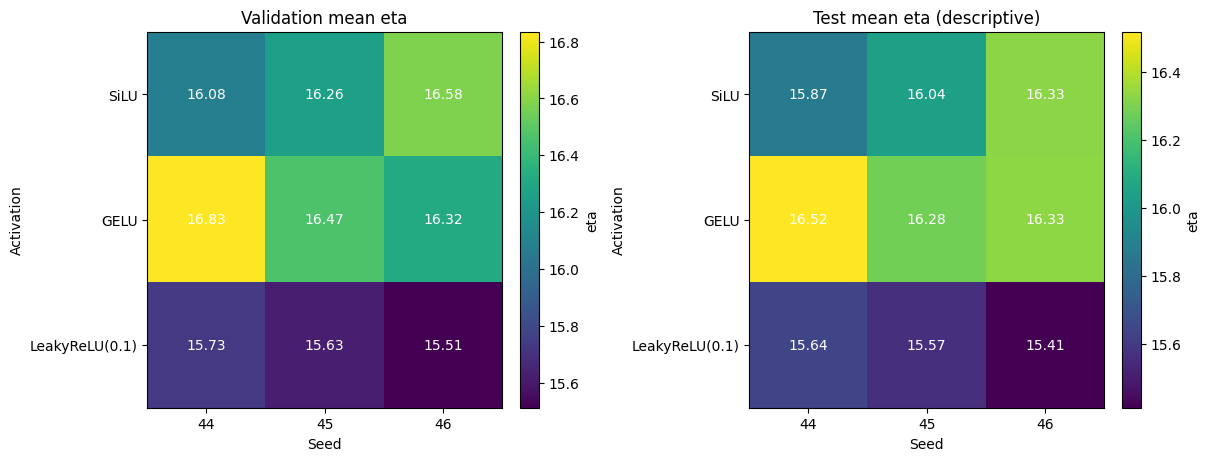

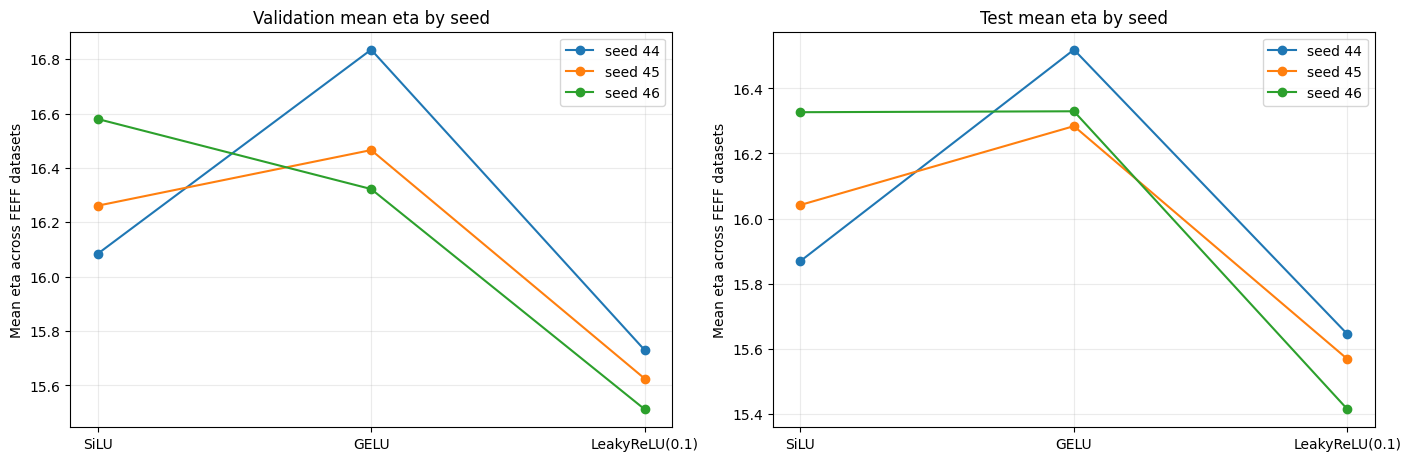

In [6]:
fig,axes=plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True)
for axis,frame,title in [(axes[0],validation_candidate_summary,"Validation mean eta"),(axes[1],test_candidate_summary,"Test mean eta (descriptive)")]:
    grid=frame.pivot(index="activation",columns="seed",values="mean_eta").reindex(index=ACTIVATIONS,columns=SEEDS); image=axis.imshow(grid.to_numpy(float),aspect="auto",cmap="viridis")
    axis.set_xticks(range(3),SEEDS); axis.set_yticks(range(3),ACTIVATIONS); axis.set_xlabel("Seed"); axis.set_ylabel("Activation"); axis.set_title(title)
    for row in range(3):
        for column in range(3): axis.text(column,row,f"{grid.iloc[row,column]:.2f}",ha="center",va="center",color="white")
    fig.colorbar(image,ax=axis,label="eta")
plt.show()
fig,axes=plt.subplots(1,2,figsize=(14,4.5),constrained_layout=True)
for axis,frame,title in [(axes[0],validation_candidate_summary,"Validation mean eta by seed"),(axes[1],test_candidate_summary,"Test mean eta by seed")]:
    for seed in SEEDS:
        subset=frame[frame.seed==seed].set_index("activation").reindex(ACTIVATIONS); axis.plot(ACTIVATIONS,subset.mean_eta,marker="o",label=f"seed {seed}")
    axis.set_title(title); axis.set_ylabel("Mean eta across FEFF datasets"); axis.grid(alpha=.25); axis.legend()
plt.show()


## 7. Activation means, seed sensitivity, and ranking stability

Activation summaries average the three seed-level candidates. The seed table shows sensitivity within each activation. The ranking tables show whether the activation order remains stable across seeds and elements.


In [7]:
def activation_stats(frame):
    return frame.groupby("activation")["mean_eta"].agg(mean="mean",median="median",std="std",min="min",max="max").reindex(ACTIVATIONS).rename_axis("activation").reset_index()
activation_summary=activation_stats(validation_candidate_summary); test_activation_summary=activation_stats(test_candidate_summary)
print("Validation activation summary across seeds:"); display(activation_summary)
print("Test activation summary across seeds:"); display(test_activation_summary)
seed_sensitivity=validation_candidate_summary.pivot(index="activation",columns="seed",values="mean_eta").reindex(index=ACTIVATIONS,columns=SEEDS); seed_sensitivity["seed_mean"]=seed_sensitivity[SEEDS].mean(axis=1); seed_sensitivity["seed_std"]=seed_sensitivity[SEEDS].std(axis=1,ddof=1); seed_sensitivity["seed_range"]=seed_sensitivity[SEEDS].max(axis=1)-seed_sensitivity[SEEDS].min(axis=1)
print("Validation seed sensitivity within each activation:"); display(seed_sensitivity.reset_index())
seed_rank_table=seed_sensitivity[SEEDS].rank(axis=0,method="min",ascending=False).astype(int); print("Validation activation ranks by seed, with 1 as best:"); display(seed_rank_table)
per_element_activation=validation_eval.groupby(["dataset","activation"],as_index=False).val_eta.mean(); element_activation_grid=per_element_activation.pivot(index="dataset",columns="activation",values="val_eta").reindex(index=FEFF_TASKS,columns=ACTIVATIONS); element_activation_ranks=element_activation_grid.rank(axis=1,method="min",ascending=False).astype(int); element_activation_winners=element_activation_grid.idxmax(axis=1).rename("validation_winner_activation").to_frame()
print("Mean validation eta by element and activation, averaged over seeds:"); display(element_activation_grid); print("Activation ranks by element:"); display(element_activation_ranks); print("Validation-winning activation by element:"); display(element_activation_winners)
print("Top activation by seed:",seed_sensitivity[SEEDS].idxmax(axis=0).to_dict()); print("Activation ranking is identical across seeds:",bool(seed_rank_table.nunique(axis=1).eq(1).all())); print("Top activation is identical across elements:",bool(element_activation_winners.validation_winner_activation.nunique()==1))


Validation activation summary across seeds:


,activation,mean,median,std,min,max
0,SiLU,16.308300,16.261040,0.251279,16.084007,16.579853
1,GELU,16.540876,16.465573,0.264417,16.322279,16.834777
2,LeakyReLU(0.1),15.622618,15.625260,0.108849,15.512472,15.730123


Test activation summary across seeds:


,activation,mean,median,std,min,max
0,SiLU,16.079207,16.041617,0.231262,15.869043,16.326961
1,GELU,16.377758,16.329785,0.124731,16.284137,16.519353
2,LeakyReLU(0.1),15.541593,15.567504,0.117638,15.413160,15.644116


Validation seed sensitivity within each activation:


...

Activation ranks by element:


activation,SiLU,GELU,LeakyReLU(0.1)
dataset,,,
Ti_FEFF,2,1,3
V_FEFF,2,1,3
Cr_FEFF,2,1,3
Mn_FEFF,2,1,3
Fe_FEFF,2,1,3
Co_FEFF,2,1,3
Ni_FEFF,2,1,3
Cu_FEFF,2,1,3


Validation-winning activation by element:


,validation_winner_activation
dataset,
Ti_FEFF,GELU
V_FEFF,GELU
Cr_FEFF,GELU
Mn_FEFF,GELU
Fe_FEFF,GELU
Co_FEFF,GELU
Ni_FEFF,GELU
Cu_FEFF,GELU


Top activation by seed: {44: 'GELU', 45: 'GELU', 46: 'SiLU'}
Activation ranking is identical across seeds: False
Top activation is identical across elements: True


## 8. Validation-only winners and their test reporting

The global winner and each per-element winner are selected from validation eta only. The next table reports the already calculated test eta for those candidates. No test value enters selection.


In [8]:
global_val_winner=validation_candidate_summary.sort_values(["mean_eta","candidate"],ascending=[False,True]).iloc[0]
per_element_val_winners=validation_eval.loc[validation_eval.groupby("dataset").val_eta.idxmax(),["dataset","candidate","activation","seed","val_eta"]].sort_values("dataset").reset_index(drop=True)
selected_rows=[]
for task in FEFF_TASKS:
    g=validation_eval[(validation_eval.candidate==global_val_winner.candidate)&(validation_eval.dataset==task)].iloc[0]; t=test_eval[(test_eval.candidate==global_val_winner.candidate)&(test_eval.dataset==task)].iloc[0]; selected_rows.append({"selection_scope":"global validation winner","dataset":task,"candidate":g.candidate,"activation":g.activation,"seed":g.seed,"val_eta":g.val_eta,"test_eta":t.test_eta})
for _,winner in per_element_val_winners.iterrows():
    t=test_eval[(test_eval.candidate==winner.candidate)&(test_eval.dataset==winner.dataset)].iloc[0]; selected_rows.append({"selection_scope":"per-element validation winner","dataset":winner.dataset,"candidate":winner.candidate,"activation":winner.activation,"seed":winner.seed,"val_eta":winner.val_eta,"test_eta":t.test_eta})
selected_test_for_reporting=pd.DataFrame(selected_rows)
print("Global validation winner:"); display(global_val_winner.to_frame().T); print("Per-element validation winners:"); display(per_element_val_winners); print("Test eta for validation-selected candidates:"); display(selected_test_for_reporting)


Global validation winner:


,candidate,activation,seed,mean_eta,median_eta,mean_mse,rank
0,gelu_seed44,GELU,44,16.834777,14.999797,0.002617,1


Per-element validation winners:


,dataset,candidate,activation,seed,val_eta
0,Co_FEFF,gelu_seed45,GELU,45,28.549936
1,Cr_FEFF,gelu_seed44,GELU,44,15.346666
2,Cu_FEFF,gelu_seed46,GELU,46,6.561418
3,Fe_FEFF,gelu_seed44,GELU,44,14.652928
4,Mn_FEFF,gelu_seed44,GELU,44,29.008125
5,Ni_FEFF,silu_seed46,SiLU,46,17.455055
6,Ti_FEFF,gelu_seed44,GELU,44,10.249469
7,V_FEFF,gelu_seed45,GELU,45,13.708478


Test eta for validation-selected candidates:


,selection_scope,dataset,candidate,activation,seed,val_eta,test_eta
0,global validation winner,Ti_FEFF,gelu_seed44,GELU,44,10.249469,10.888380
1,global validation winner,V_FEFF,gelu_seed44,GELU,44,13.116949,11.761620
2,global validation winner,Cr_FEFF,gelu_seed44,GELU,44,15.346666,17.689799
3,global validation winner,Mn_FEFF,gelu_seed44,GELU,44,29.008125,27.999312
4,global validation winner,Fe_FEFF,gelu_seed44,GELU,44,14.652928,14.309441
5,global validation winner,Co_FEFF,gelu_seed44,GELU,44,28.478431,27.458567
6,global validation winner,Ni_FEFF,gelu_seed44,GELU,44,17.383868,15.582674
7,global validation winner,Cu_FEFF,gelu_seed44,GELU,44,6.441777,6.465032
8,per-element validation winner,Co_FEFF,gelu_seed45,GELU,45,28.549936,26.950719
9,per-element validation winner,Cr_FEFF,gelu_seed44,GELU,44,15.346666,17.689799


## 9. Protocol reference: completed balanced GELU UniversalXAS run

When available, `train_balanced_gelu_universal_tuned_feff/universal_eval.csv` provides a separate protocol reference. It uses balanced sampling. It is not another activation-sweep candidate and remains separate from the unbalanced activation sweep.


In [9]:
if BALANCED_REFERENCE_PATH.is_file():
    balanced_reference=pd.read_csv(BALANCED_REFERENCE_PATH); require_columns(balanced_reference,["dataset","activation","seed","val_eta","test_eta"],"balanced GELU universal_eval.csv")
    if len(balanced_reference)!=8 or set(balanced_reference.dataset)!=set(FEFF_TASKS): raise AssertionError("Balanced GELU reference must have one row for each FEFF dataset")
    finite(balanced_reference,["val_eta","test_eta"],"balanced GELU universal_eval.csv"); print("Balanced GELU protocol reference:"); display(balanced_reference[["dataset","activation","seed","val_eta","test_eta"]].sort_values("dataset"))
    balanced_comparison=test_eval.merge(balanced_reference[["dataset","test_eta"]].rename(columns={"test_eta":"balanced_gelu_test_eta"}),on="dataset",validate="many_to_one"); balanced_comparison["candidate_minus_balanced_test_eta"]=balanced_comparison.test_eta-balanced_comparison.balanced_gelu_test_eta; balanced_comparison["candidate_minus_balanced_percent"]=100*balanced_comparison.candidate_minus_balanced_test_eta/balanced_comparison.balanced_gelu_test_eta
    print("All activation candidates compared with balanced GELU:"); display(balanced_comparison[["candidate","activation","seed","dataset","test_eta","balanced_gelu_test_eta","candidate_minus_balanced_test_eta","candidate_minus_balanced_percent"]].sort_values(["dataset","candidate"]))
    balanced_mean=float(balanced_reference.test_eta.mean()); balanced_vs_activation=test_activation_summary[["activation","mean"]].rename(columns={"mean":"activation_mean_test_eta"}); balanced_vs_activation["balanced_gelu_mean_test_eta"]=balanced_mean; balanced_vs_activation["activation_minus_balanced"]=balanced_vs_activation.activation_mean_test_eta-balanced_mean; display(balanced_vs_activation)
else:
    balanced_reference=balanced_comparison=None; balanced_mean=None; print(f"Balanced GELU protocol reference is not available: {BALANCED_REFERENCE_PATH}")


Balanced GELU protocol reference:


,dataset,activation,seed,val_eta,test_eta
0,Co_FEFF,GELU,44,27.344196,27.133866
1,Cr_FEFF,GELU,44,15.228841,18.498384
2,Cu_FEFF,GELU,44,6.724983,6.778938
3,Fe_FEFF,GELU,44,14.558698,14.163801
4,Mn_FEFF,GELU,44,27.627024,26.138724
5,Ni_FEFF,GELU,44,17.978096,15.643909
6,Ti_FEFF,GELU,44,10.401226,11.206467
7,V_FEFF,GELU,44,13.113885,11.538162


All activation candidates compared with balanced GELU:


,candidate,activation,seed,dataset,test_eta,balanced_gelu_test_eta,candidate_minus_balanced_test_eta,candidate_minus_balanced_percent
29,gelu_seed44,GELU,44,Co_FEFF,27.458567,27.133866,0.324701,1.196663
37,gelu_seed45,GELU,45,Co_FEFF,26.950719,27.133866,-0.183147,-0.674977
45,gelu_seed46,GELU,46,Co_FEFF,26.976537,27.133866,-0.157329,-0.579825
53,leakyrelu_0p1_seed44,LeakyReLU(0.1),44,Co_FEFF,25.106061,27.133866,-2.027806,-7.473338
61,leakyrelu_0p1_seed45,LeakyReLU(0.1),45,Co_FEFF,26.149803,27.133866,-0.984063,-3.626696
...,...,...,...,...,...,...,...,...
57,leakyrelu_0p1_seed45,LeakyReLU(0.1),45,V_FEFF,10.810634,11.538162,-0.727528,-6.305403
65,leakyrelu_0p1_seed46,LeakyReLU(0.1),46,V_FEFF,11.076797,11.538162,-0.461365,-3.998600
1,silu_seed44,SiLU,44,V_FEFF,11.242489,11.538162,-0.295673,-2.562563
9,silu_seed45,SiLU,45,V_FEFF,11.430310,11.538162,-0.107852,-0.934743


,activation,activation_mean_test_eta,balanced_gelu_mean_test_eta,activation_minus_balanced
0,SiLU,16.079207,16.387781,-0.308574
1,GELU,16.377758,16.387781,-0.010023
2,LeakyReLU(0.1),15.541593,16.387781,-0.846188


## 10. Directional comparison with paper FEFF UniversalXAS eta

The paper FEFF UniversalXAS eta values are Ti 4.19, V 5.19, Cr 7.13, Mn 13.15, Fe 6.04, Co 9.58, Ni 6.43, and Cu 2.75. The table compares every activation candidate test eta with the matching paper value.

The comparison is directional. The activation sweep uses custom exported scratch-encoder features. The paper uses the pinned frozen `M3GNet-MP-2021.2.8-PES` feature-transfer pipeline. The balanced GELU reference also changes the loader protocol through balanced sampling.


In [10]:
paper_rows=test_eval.copy(); paper_rows["element"]=paper_rows.dataset.str.removesuffix("_FEFF"); paper_rows["paper_universal_eta"]=paper_rows.element.map(PAPER_UNIVERSAL_ETA); paper_rows["signed_difference"]=paper_rows.test_eta-paper_rows.paper_universal_eta; paper_rows["percent_difference"]=100*paper_rows.signed_difference/paper_rows.paper_universal_eta; paper_rows["comparison_scope"]="Directional: custom scratch-encoder features versus pinned frozen M3GNet feature transfer"
print("All activation candidate test eta values versus paper FEFF UniversalXAS eta:"); display(paper_rows[["candidate","activation","seed","dataset","test_eta","paper_universal_eta","signed_difference","percent_difference"]].sort_values(["dataset","candidate"]))


All activation candidate test eta values versus paper FEFF UniversalXAS eta:


,candidate,activation,seed,dataset,test_eta,paper_universal_eta,signed_difference,percent_difference
29,gelu_seed44,GELU,44,Co_FEFF,27.458567,9.58,17.878567,186.623874
37,gelu_seed45,GELU,45,Co_FEFF,26.950719,9.58,17.370719,181.322742
45,gelu_seed46,GELU,46,Co_FEFF,26.976537,9.58,17.396537,181.592246
53,leakyrelu_0p1_seed44,LeakyReLU(0.1),44,Co_FEFF,25.106061,9.58,15.526061,162.067438
61,leakyrelu_0p1_seed45,LeakyReLU(0.1),45,Co_FEFF,26.149803,9.58,16.569803,172.962455
...,...,...,...,...,...,...,...,...
57,leakyrelu_0p1_seed45,LeakyReLU(0.1),45,V_FEFF,10.810634,5.19,5.620634,108.297387
65,leakyrelu_0p1_seed46,LeakyReLU(0.1),46,V_FEFF,11.076797,5.19,5.886797,113.425762
1,silu_seed44,SiLU,44,V_FEFF,11.242489,5.19,6.052489,116.618291
9,silu_seed45,SiLU,45,V_FEFF,11.430310,5.19,6.240310,120.237183


## 11. Conclusions

The statements below separate validation selection from descriptive test reporting. Only a validation-selected candidate should support a final unbiased test claim.


In [11]:
global_test=selected_test_for_reporting[selected_test_for_reporting.selection_scope=="global validation winner"].set_index("dataset"); best_element=global_test.test_eta.idxmax(); worst_element=global_test.test_eta.idxmin()
print(f"Best global validation candidate: {global_val_winner.candidate} ({global_val_winner.activation}, seed {int(global_val_winner.seed)}), with mean validation eta {global_val_winner.mean_eta:.3f}.")
print("Validation activation means: "+"; ".join(f"{r.activation}={r['mean']:.3f}" for _,r in activation_summary.iterrows()))
print("Validation seed sensitivity ranges: "+"; ".join(f"{a}={seed_sensitivity.loc[a,'seed_range']:.3f}" for a in ACTIVATIONS))
print(f"Activation ranking is stable across seeds: {bool(seed_rank_table.nunique(axis=1).eq(1).all())}.")
print(f"The validation-selected global candidate has best test eta on {best_element} ({global_test.loc[best_element,'test_eta']:.3f}) and worst test eta on {worst_element} ({global_test.loc[worst_element,'test_eta']:.3f}).")
if balanced_mean is None: print("The balanced GELU reference is unavailable, so no protocol comparison is reported.")
else:
    gelu_mean=float(test_activation_summary.loc[test_activation_summary.activation=="GELU","mean"].iloc[0]); direction="higher" if balanced_mean>gelu_mean else "lower"; print(f"Balanced GELU reference mean test eta is {balanced_mean:.3f}. The unbalanced GELU mean is {gelu_mean:.3f}; the balanced reference is {direction} under its different loader protocol.")
print("The scratch-encoder and paper comparison is directional, not a paper reproduction."); print("Use only validation-selected candidates for a final unbiased test claim. Do not select from the all-candidate test table.")


Best global validation candidate: gelu_seed44 (GELU, seed 44), with mean validation eta 16.835.
Validation activation means: SiLU=16.308; GELU=16.541; LeakyReLU(0.1)=15.623
Validation seed sensitivity ranges: SiLU=0.496; GELU=0.512; LeakyReLU(0.1)=0.218
Activation ranking is stable across seeds: False.
The validation-selected global candidate has best test eta on Mn_FEFF (27.999) and worst test eta on Cu_FEFF (6.465).
Balanced GELU reference mean test eta is 16.388. The unbalanced GELU mean is 16.378; the balanced reference is higher under its different loader protocol.
The scratch-encoder and paper comparison is directional, not a paper reproduction.
Use only validation-selected candidates for a final unbiased test claim. Do not select from the all-candidate test table.


## 12. Final self-checks

These checks confirm paths, manifest count, nine candidates, 72 stored validation rows, 72 all-candidate test rows, eight FEFF datasets, 64/141 dimensions, finite metrics, complete checkpoints, and validation-only selection consistency.


In [12]:
assert REPO_ROOT.is_dir() and ARCHIVE_RUN.is_dir() and SWEEP_ROOT.is_dir() and RESULTS_DIR.is_dir() and CANDIDATES_DIR.is_dir()
assert manifest_path.is_file() and summary_path.is_file() and validation_path.is_file(); assert manifest.get("candidate_count")==9; assert len(expected_ids)==9; assert len(candidate_summary_stored)==9; assert len(candidate_validation_stored)==72; assert len(validation_eval)==72; assert len(test_eval)==72
assert set(validation_eval.candidate)==expected_ids and set(test_eval.candidate)==expected_ids and set(validation_eval.dataset)==set(FEFF_TASKS) and set(test_eval.dataset)==set(FEFF_TASKS); assert validation_eval.groupby("candidate").dataset.size().eq(8).all(); assert test_eval.groupby("candidate").dataset.size().eq(8).all()
assert set(shape_df.feature_dim)=={64} and set(shape_df.target_dim)=={141} and len(shape_df)==24; assert all(path.is_file() for path in candidate_checkpoints.values()); assert np.isfinite(validation_eval.select_dtypes(include=[np.number]).to_numpy()).all(); assert np.isfinite(test_eval.select_dtypes(include=[np.number]).to_numpy()).all()
assert global_val_winner.candidate==validation_candidate_summary.sort_values(["mean_eta","candidate"],ascending=[False,True]).iloc[0].candidate
expected_element_candidates=validation_eval.loc[validation_eval.groupby("dataset").val_eta.idxmax(),["dataset","candidate"]].sort_values("dataset").reset_index(drop=True); observed_element_candidates=per_element_val_winners[["dataset","candidate"]].sort_values("dataset").reset_index(drop=True); pd.testing.assert_frame_equal(expected_element_candidates,observed_element_candidates,check_dtype=False)
print("All final self-checks passed.")


All final self-checks passed.
